## Ejercicio 1.
Implemente la arquitectura para una red recurrente de Hopfield con su entrenamiento hebbiano y pruébela con los patrones que se muestran en la siguiente figura.

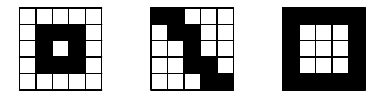


#### Problemas con estos tipos de patrones

Interferencia por Similitud (**Crosstalk**): La regla de aprendizaje de Hebb requiere que los patrones sean ortogonales (estadísticamente independientes) para no sobrescribirse. Si comparas el Patrón 1 con el inverso del Patrón 3, estos comparten 24 de los 25 píxeles; solo difieren en el punto central. Al calcular $W = \frac{1}{N} \sum X^T X$, esta similitud extrema hace que la red sume la forma "cuadrada" dos veces. Esto crea un "pozo gravitacional" (atractor) con el doble de fuerza y profundidad que el atractor de la diagonal (Patrón 2).

#### Cargar datos de entrada


Forma de la matriz de entrada X: (3, 25)


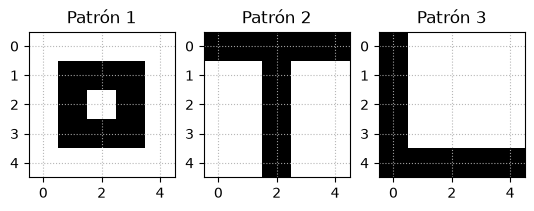

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# Codificación: 1 = Cuadro Negro, -1 = Cuadro Blanco


## --- Pruebo con patrones no tan similares entre sí ---
# Patrón 1.
p1 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  1,  1,  1, -1],
    [-1,  1, -1,  1, -1],
    [-1,  1,  1,  1, -1],
    [-1, -1, -1, -1, -1]
])

# Patrón 2.
p2 = np.array([
    [ 1,  1,  1,  1,  1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1]
])

# Patrón 3.
p3 = np.array([
    [ 1, -1, -1, -1, -1],
    [ 1, -1, -1, -1, -1],
    [ 1, -1, -1, -1, -1],
    [ 1, -1, -1, -1, -1],
    [ 1,  1,  1,  1,  1]
])

plt.figure(1)
ax = plt.subplot(1,3,1)
ax.imshow(p1, cmap='Greys')
ax.grid(True, linestyle=':', alpha=0.9)
ax.set_title("Patrón 1")

ax = plt.subplot(1,3,2)
ax.imshow(p2, cmap='Greys')
ax.grid(True, linestyle=':', alpha=0.9)
ax.set_title("Patrón 2")

ax = plt.subplot(1,3,3)
ax.imshow(p3, cmap='Greys')
ax.grid(True, linestyle=':', alpha=0.9)
ax.set_title("Patrón 3")


# Para usarlos como entradas (X) en redes neuronales, conviene 'aplanarlos' (flatten):
# Esto convierte cada matriz de 5x5 en un vector 1D de 25 elementos.
X_patrones = np.array([
    p1.flatten(),
    p2.flatten(),
    p3.flatten()
])

print(f"Forma de la matriz de entrada X: {X_patrones.shape}")

### Entrenamiento de la red (Almacenamiento)

In [9]:
## Forma vectorial para calcular los pesos:
def entrenar_hopfield(X_patrones):
    # X_patrones tiene forma (M, N) con valores en {-1, +1}
    M, N = X_patrones.shape
    
    # Producto externo vectorial acumulado
    W = (1.0 / N) * np.dot(X_patrones.T, X_patrones)
    
    # Imponer diagonal nula (sin autoconexiones)
    np.fill_diagonal(W, 0.0)
    
    return W


### Prueba (Recuperación)

In [10]:
## Forma de recuperación asíncrona:
def recuperar_memoria_asincrona(y_ruidoso, W, max_iter=500):
    y = y_ruidoso.copy()
    N = len(y)
    
    for iteracion in range(max_iter):
        y_previo = y.copy()
        
        # Seleccionar orden aleatorio de neuronas a actualizar
        indices = np.random.permutation(N)
        
        for j in indices:
            # Campo local neto: sum(W_ji * y_i)
            campo_local = np.dot(W[j, :], y)
            
            # Regla de activación bipolar sgn
            if campo_local > 0:
                y[j] = 1
            elif campo_local < 0:
                y[j] = -1
            # Si campo_local == 0, y[j] no cambia
            
        # Verificar criterio de parada (punto fijo alcanzado)
        if np.array_equal(y, y_previo):
            print(f"Convergencia alcanzada en la iteración {iteracion + 1}.")
            break
            
    return y

def capacidad_max_almacenamiento(X_patrones):

    N = X_patrones.shape[1]

    return N / (2*np.log(N))


###  Entrenar la red:
W = entrenar_hopfield(X_patrones)
P_max = capacidad_max_almacenamiento(X_patrones)

print(f"Capacidad máxima de almacenamiento para la red: {P_max}\n")


Capacidad máxima de almacenamiento para la red: 3.883343340997574



## Código de pruebas

Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[-1 -1 -1 -1 -1 -1  1  1  1 -1 -1  1 -1  1 -1 -1  1  1  1 -1 -1 -1 -1 -1
 -1]


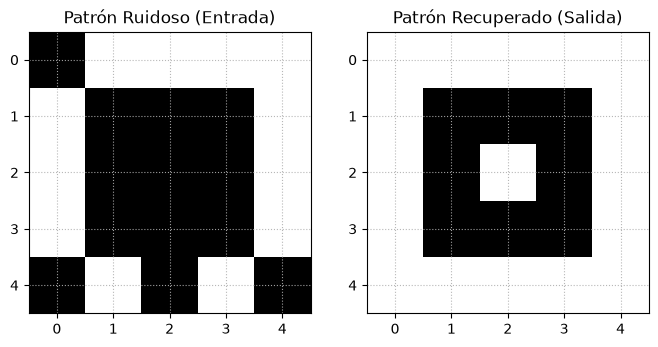

In [11]:

## --- Prueba con patron 1 ruidoso:
y_0 = np.array([
    [ 1, -1, -1, -1, -1],
    [-1,  1,  1,  1, -1],
    [-1,  1,  1,  1, -1],
    [-1,  1,  1,  1, -1],
    [ 1, -1,  1, -1,  1]
])


y_0_flat = y_0.flatten()
y_d = recuperar_memoria_asincrona(y_0_flat, W, 300)

print(f"Prueba de recuperación y:\n{y_d}")

# volver a darle forma de matriz 5x5 para graficarlo
y_d_matriz = y_d.reshape((5, 5))


plt.figure(figsize=(8, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(y_0, cmap='Greys')
ax1.grid(True, linestyle=':', alpha=0.9)
ax1.set_title("Patrón Ruidoso (Entrada)")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(y_d_matriz, cmap='Greys')
ax2.grid(True, linestyle=':', alpha=0.9)
ax2.set_title("Patrón Recuperado (Salida)")

plt.show()



Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[ 1  1  1  1  1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1
 -1]


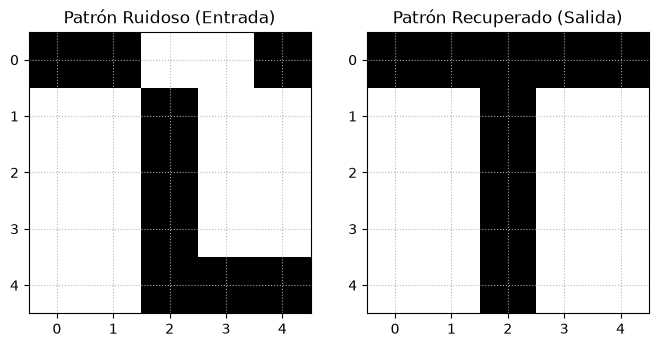

In [12]:

## --- Prueba con patron 2 ruidoso:
y_0 = np.array([
    [ 1,  1, -1, -1,  1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1, -1, -1],
    [-1, -1,  1,  1,  1]
])


y_0_flat = y_0.flatten()
y_d = recuperar_memoria_asincrona(y_0_flat, W, 300)

print(f"Prueba de recuperación y:\n{y_d}")

# volver a darle forma de matriz 5x5 para graficarlo
y_d_matriz = y_d.reshape((5, 5))


plt.figure(figsize=(8, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(y_0, cmap='Greys')
ax1.grid(True, linestyle=':', alpha=0.9)
ax1.set_title("Patrón Ruidoso (Entrada)")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(y_d_matriz, cmap='Greys')
ax2.grid(True, linestyle=':', alpha=0.9)
ax2.set_title("Patrón Recuperado (Salida)")

plt.show()



Convergencia alcanzada en la iteración 2.
Prueba de recuperación y:
[ 1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1  1  1  1
  1]


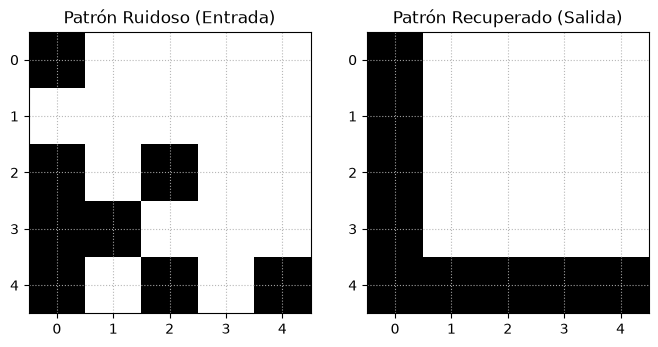

In [13]:

## --- Prueba con patron 3 ruidoso:
y_0 = np.array([
    [ 1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [ 1, -1,  1, -1, -1],
    [ 1,  1, -1, -1, -1],
    [ 1, -1,  1, -1,  1]
])


y_0_flat = y_0.flatten()
y_d = recuperar_memoria_asincrona(y_0_flat, W, 300)

print(f"Prueba de recuperación y:\n{y_d}")

# volver a darle forma de matriz 5x5 para graficarlo
y_d_matriz = y_d.reshape((5, 5))


plt.figure(figsize=(8, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(y_0, cmap='Greys')
ax1.grid(True, linestyle=':', alpha=0.9)
ax1.set_title("Patrón Ruidoso (Entrada)")

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(y_d_matriz, cmap='Greys')
ax2.grid(True, linestyle=':', alpha=0.9)
ax2.set_title("Patrón Recuperado (Salida)")

plt.show()

